### 매뉴얼 - 엘라스틱넷 다항 회귀 (ElasticNet Polynomial Regression)

본 노트북은 AI 컴패니언 의존도(정서적 애착도 `emotional_attachment_score`)를 예측하기 위해, **$L_1$ 규제(Lasso, 변수 선택/희소성)**와 **$L_2$ 규제(Ridge, 다중공선성 완화/가중치 축소)**의 장점을 결합한 **ElasticNet(엘라스틱넷)** 알고리즘을 2차 다항 특성 데이터에 적용하고 최적의 하이퍼파라미터를 튜닝 및 평가한다.

In [1]:
import os
import platform
import pandas as pd
import numpy as np
from IPython.display import display # 피쳐가 많은 해당 데이터를 좀 더 보기 쉽도록 하기 위해 불러온다.
import matplotlib.pyplot as plt
import seaborn as sns

# 한글 폰트 설정(모든 OS에서 작동되도록)
if platform.system() == 'Darwin':       # macOS
    plt.rc('font', family='AppleGothic')
elif platform.system() == 'Windows':    # Windows
    plt.rc('font', family='Malgun Gothic')
else:                                   # Linux / Docker / Cloud
    plt.rc('font', family='NanumGothic')
plt.rcParams['axes.unicode_minus'] = False


# 데이터 로드: ai_companion_dependency_dataset.csv
data= pd.read_csv('data/ai_companion_dependency_dataset.csv')


# 데이터 상위 5열 확인으로 컬럼(피쳐) 파악
print(data.head())

print(data.describe())

  user_id  age      gender   occupation_status education_level  income_level  \
0   U0001   21        Male  Employed Full-Time     High School  Lower-Middle   
1   U0002   34        Male             Student        Graduate  Upper-Middle   
2   U0003   43        Male  Employed Full-Time        Graduate           Low   
3   U0004   29  Non-binary  Employed Full-Time        Graduate           Low   
4   U0005   25      Female             Student        Graduate  Upper-Middle   

  relationship_status living_situation country_region ai_chatbot_platform  \
0   In a Relationship     With Partner  South America             ChatGPT   
1              Single            Alone  North America        Character.AI   
2              Single            Alone         Europe        Character.AI   
3              Single      With Family           Asia             ChatGPT   
4   In a Relationship   With Roommates  South America             ChatGPT   

   ... sleep_hours  sleep_quality_score  exercise_hours_

In [2]:
from sklearn.preprocessing import OneHotEncoder
import pandas as pd
import numpy as np
from IPython.display import display

# ===========================================================================================================
# 1. 데이터 필터링-행 :: (청소년, 넓게는 청년층과 AI에 대한 심리적 문제가 대상이므로, 특정 연령대와 특정 이용목적만을 남긴다.)
# ===========================================================================================================

"""
age: 15세 ~ 24세 (청소년층 / 청년층)
primary_use_cases : Companionship, Entertainment, Therapy-Substitute
"""
target_col = ['Companionship', 'Entertainment', 'Therapy-Substitute']

df_filtered = data[
    (data['age'] >= 15) & (data['age'] <= 24) &
    (data['primary_use_case'].isin(target_col))
].copy()


# ===========================================================================================================
# 2. 데이터 필터링-열 :: 수치형 피처 + 보류했던 범주형 3개 피처만 선택
# ===========================================================================================================

"""
[제외 피쳐 목록]
user_id, gender, country_region, ai_chatbot_platform, prefers_ai_over_humans,
academic_or_work_performance_change, dependency_risk_label,
education_level, income_level, primary_use_case, therapy_attendance

[보류에서 -> 분석 대상으로 추가된 피쳐 3종]
- occupation_status (직업 상태)
- relationship_status (연애/대인 관계 상태)
- living_situation (주거 형태)
"""

# 포함할 분석 대상 피쳐 선택 (수치형 15개 + 보류 피처 3개 + 타깃 1개 = 총 19개)
selected_features = [
    # 기본 인구통계 및 [보류 해제 피처 3개]
    'age',
    'occupation_status',        # [추가] 직업 상태
    'relationship_status',      # [추가] 연애/결혼 상태
    'living_situation',         # [추가] 주거 형태
    
    # 일상 및 디지털 활동 시간 (수치형)
    'daily_ai_chat_hours',
    'human_social_interaction_hours',
    'social_media_hours_daily',
    'screen_time_total_hours',
    
    # 사회적 관계 (수치형)
    'number_of_close_friends',
    'real_relationship_satisfaction',
    
    # 생활 습관 및 수면 (수치형)
    'sleep_hours',
    'sleep_quality_score',
    'exercise_hours_weekly',
    
    # 심리적 척도 (수치형)
    'loneliness_score',
    'anxiety_score',
    'depression_score',
    'stress_score',
    'self_esteem_score',
    
    # 종속 변수 (Target)
    'emotional_attachment_score'
]

# 1차 필터링 데이터프레임 생성
df = df_filtered[selected_features].reset_index(drop=True)

print(f"원본 데이터 크기: {data.shape}")
print(f"필터링 데이터 크기: {df.shape}")

# 필터링한 데이터의 결측치 확인
print(df.isnull().sum())



# ===========================================================================================================
# 3. 오직 [보류 피처 3개]만 원-핫 인코딩 수행 (OneHotEncoder)
# ===========================================================================================================

# 1) 원-핫 인코딩할 3개 피처 지정
categorical_features = ['occupation_status', 'relationship_status', 'living_situation']

# 2) 순수 수치형 피처 목록
numeric_features = [
    'age', 'daily_ai_chat_hours', 'human_social_interaction_hours', 
    'social_media_hours_daily', 'screen_time_total_hours', 'number_of_close_friends', 
    'real_relationship_satisfaction', 'sleep_hours', 'sleep_quality_score', 
    'exercise_hours_weekly', 'loneliness_score', 'anxiety_score', 
    'depression_score', 'stress_score', 'self_esteem_score'
]

target_feature = 'emotional_attachment_score'

# 3) OneHotEncoder로 3개 피처만 변환 (다중공선성 방지 drop='first')
ohe = OneHotEncoder(drop='first', sparse_output=False, handle_unknown='ignore')
encoded_array = ohe.fit_transform(df[categorical_features])
encoded_columns = ohe.get_feature_names_out(categorical_features)

df_encoded_cats = pd.DataFrame(encoded_array, columns=encoded_columns)

# 4) 수치형 피처 + 인코딩된 3개 범주형 피처 + 타깃 결합
df_final = pd.concat([df[numeric_features], df_encoded_cats, df[[target_feature]]], axis=1)

# 5) 독립변수 X와 종속변수 y 분리
X = df_final.drop(columns=[target_feature])
y = df_final[target_feature]

# ===========================================================================================================
# 4. 최종 데이터 확인
# ===========================================================================================================
print("\n" + "="*70)
print(f"최종 전처리 완료 데이터 크기: {df_final.shape}")
print(f"독립변수(X) 피처 개수: {X.shape[1]}개 | 종속변수(y) 크기: {y.shape[0]}개")
print("="*70)

print("\n--- [추가된 3개 피처의 더미 컬럼 목록] ---")
print(encoded_columns.tolist())

print("\n--- [최종 데이터 상위 5개 행 (X)] ---")
display(X.head())

원본 데이터 크기: (1000, 30)
필터링 데이터 크기: (196, 19)
age                               0
occupation_status                 0
relationship_status               0
living_situation                  0
daily_ai_chat_hours               0
human_social_interaction_hours    0
social_media_hours_daily          0
screen_time_total_hours           0
number_of_close_friends           0
real_relationship_satisfaction    0
sleep_hours                       0
sleep_quality_score               0
exercise_hours_weekly             0
loneliness_score                  0
anxiety_score                     0
depression_score                  0
stress_score                      0
self_esteem_score                 0
emotional_attachment_score        0
dtype: int64

최종 전처리 완료 데이터 크기: (196, 26)
독립변수(X) 피처 개수: 25개 | 종속변수(y) 크기: 196개

--- [추가된 3개 피처의 더미 컬럼 목록] ---
['occupation_status_Employed Part-Time', 'occupation_status_Freelancer', 'occupation_status_Student', 'occupation_status_Unemployed', 'relationship_status_In a R

,age,daily_ai_chat_hours,human_social_interaction_hours,social_media_hours_daily,screen_time_total_hours,number_of_close_friends,real_relationship_satisfaction,sleep_hours,sleep_quality_score,exercise_hours_weekly,...,occupation_status_Employed Part-Time,occupation_status_Freelancer,occupation_status_Student,occupation_status_Unemployed,relationship_status_In a Relationship,relationship_status_Married,relationship_status_Single,living_situation_With Family,living_situation_With Partner,living_situation_With Roommates
0,22,0.94,5.49,2.46,5.10,4,5.5,5.8,7.1,2.6,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
1,17,0.00,4.96,1.86,5.42,4,8.8,9.3,7.7,6.1,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0
2,16,1.47,5.18,2.70,6.23,6,3.8,8.1,5.2,5.5,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
3,24,0.00,4.91,0.65,1.79,7,10.0,7.1,7.9,4.9,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
4,17,0.00,4.43,0.52,3.03,3,8.4,9.2,9.5,4.1,...,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [3]:
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.model_selection import train_test_split

# ===========================================================================================================
# 5. 다항 특성 확장 (PolynomialFeatures) & 표준화 스케일링 (StandardScaler)
# ===========================================================================================================

# 1) 2차 다항 특성 및 상호작용 항 생성
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly = poly.fit_transform(X)
poly_feature_names = poly.get_feature_names_out(X.columns)

print(f'기존 피처 수: {X.shape[1]}개')
print(f'2차 다항 특성 변환 후 피처 수: {X_poly.shape[1]}개')

# 2) Train / Test 분할 (80:20, 동일한 난수 시드 random_state=42)
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_poly, y, test_size=0.2, random_state=42
)

# 3) 표준화 스케일링 (규제 모델 필수 전처리)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train_raw)
X_test = scaler.transform(X_test_raw)

print(f'스케일링 완료: Train셋 {X_train.shape} | Test셋 {X_test.shape}')

기존 피처 수: 25개
2차 다항 특성 변환 후 피처 수: 350개
스케일링 완료: Train셋 (156, 350) | Test셋 (40, 350)


### [이론] ElasticNet (엘라스틱넷) 이란?

ElasticNet은 **Ridge의 $L_2$ 규제**와 **Lasso의 $L_1$ 규제**를 선형 결합한 회귀 모델입니다.

$$\text{Loss} = \text{MSE} + \alpha \left( \rho \sum_{j=1}^p |w_j| + \frac{1-\rho}{2} \sum_{j=1}^p w_j^2 \right)$$

* **`alpha` ($\alpha$)**: 전체 규제 강도 (클수록 가중치가 더 강하게 억제됨)
* **`l1_ratio` ($\rho$)**: $L_1$ 페널티의 비율 ($0 \le \rho \le 1$)
  * $\rho = 1$: 순수 Lasso 회귀
  * $\rho = 0$: 순수 Ridge 회귀
  * $0 < \rho < 1$: Lasso와 Ridge의 장점을 결합 (상관관계가 높은 변수 집단을 함께 선택하면서도 가중치를 안정화)

In [4]:
from sklearn.linear_model import ElasticNetCV
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# ===========================================================================================================
# 6. ElasticNetCV를 활용한 하이퍼파라미터 (alpha, l1_ratio) 교차 검증 튜닝
# ===========================================================================================================

# 탐색할 l1_ratio 및 alpha 후보군 설정
l1_ratios = [0.1, 0.3, 0.5, 0.7, 0.8, 0.9, 0.95, 0.99]
alphas = np.logspace(-3, 2, 100)

# 5-Fold 교차 검증으로 최적 alpha 및 l1_ratio 자동 탐색
elastic_cv = ElasticNetCV(
    l1_ratio=l1_ratios,
    alphas=alphas,
    cv=5,
    max_iter=10000,
    random_state=42
)
elastic_cv.fit(X_train, y_train)

# 최적 하이퍼파라미터 확인
best_alpha = elastic_cv.alpha_
best_l1_ratio = elastic_cv.l1_ratio_

print('='*60)
print(f'최적 alpha    : {best_alpha:.5f}')
print(f'최적 l1_ratio : {best_l1_ratio:.2f}')
print('='*60)

# 성능 평가
y_train_pred_en = elastic_cv.predict(X_train)
y_test_pred_en = elastic_cv.predict(X_test)

# 평가지표 산출
train_mse = mean_squared_error(y_train, y_train_pred_en)
train_rmse = np.sqrt(train_mse)
train_r2 = r2_score(y_train, y_train_pred_en)

test_mse = mean_squared_error(y_test, y_test_pred_en)
test_rmse = np.sqrt(test_mse)
test_mae = mean_absolute_error(y_test, y_test_pred_en)
test_r2 = r2_score(y_test, y_test_pred_en)

print('\n--- [ElasticNet 다항 회귀 모델 성능 평가 결과] ---')
print(f'[Train 셋] MSE: {train_mse:.4f} | RMSE: {train_rmse:.4f} | R²: {train_r2:.4f}')
print(f'[Test  셋] MSE: {test_mse:.4f} | RMSE: {test_rmse:.4f} | MAE: {test_mae:.4f} | R²: {test_r2:.4f}')

e:\CJWAI\Project2_MLProject\DependencyOfAICompanion\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.143488e-02, tolerance: 6.867e-02
  model = cd_fast.enet_coordinate_descent(


최적 alpha    : 0.47508
최적 l1_ratio : 0.30

--- [ElasticNet 다항 회귀 모델 성능 평가 결과] ---
[Train 셋] MSE: 1.1344 | RMSE: 1.0651 | R²: 0.7824
[Test  셋] MSE: 1.4392 | RMSE: 1.1997 | MAE: 1.0279 | R²: 0.7814


전체 2차 다항 피처 개수       : 350개
L1 규제로 제거된 피처(가중치=0): 294개 (84.0%)
실제 선택된 유효 피처(가중치!=0): 56개


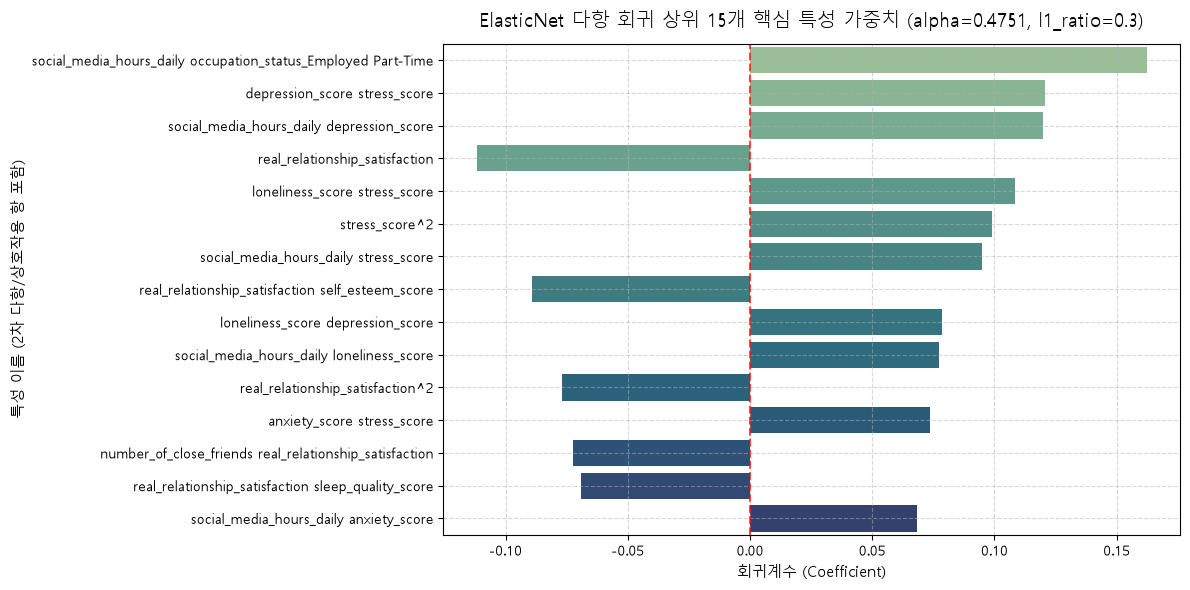

In [5]:
# ===========================================================================================================
# 7. ElasticNet 회귀계수 분석 (Feature Sparsity & 중요 피처 추출)
# ===========================================================================================================

coefs = elastic_cv.coef_
zero_coef_count = np.sum(coefs == 0)
nonzero_coef_count = np.sum(coefs != 0)

print(f'전체 2차 다항 피처 개수       : {len(coefs)}개')
print(f'L1 규제로 제거된 피처(가중치=0): {zero_coef_count}개 ({zero_coef_count/len(coefs)*100:.1f}%)')
print(f'실제 선택된 유효 피처(가중치!=0): {nonzero_coef_count}개')

# 상위 15개 중요 피처 추출 및 정렬
coef_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': coefs,
    'Abs_Coef': np.abs(coefs)
}).sort_values(by='Abs_Coef', ascending=False).head(15)

# 중요도 시각화
plt.figure(figsize=(12, 6))
sns.barplot(data=coef_df, x='Coefficient', y='Feature', hue='Feature', palette='crest', legend=False)
plt.title(f'ElasticNet 다항 회귀 상위 15개 핵심 특성 가중치 (alpha={best_alpha:.4f}, l1_ratio={best_l1_ratio})', fontsize=14, pad=12)
plt.xlabel('회귀계수 (Coefficient)', fontsize=11)
plt.ylabel('특성 이름 (2차 다항/상호작용 항 포함)', fontsize=11)
plt.axvline(0, color='red', linestyle='--', alpha=0.7)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

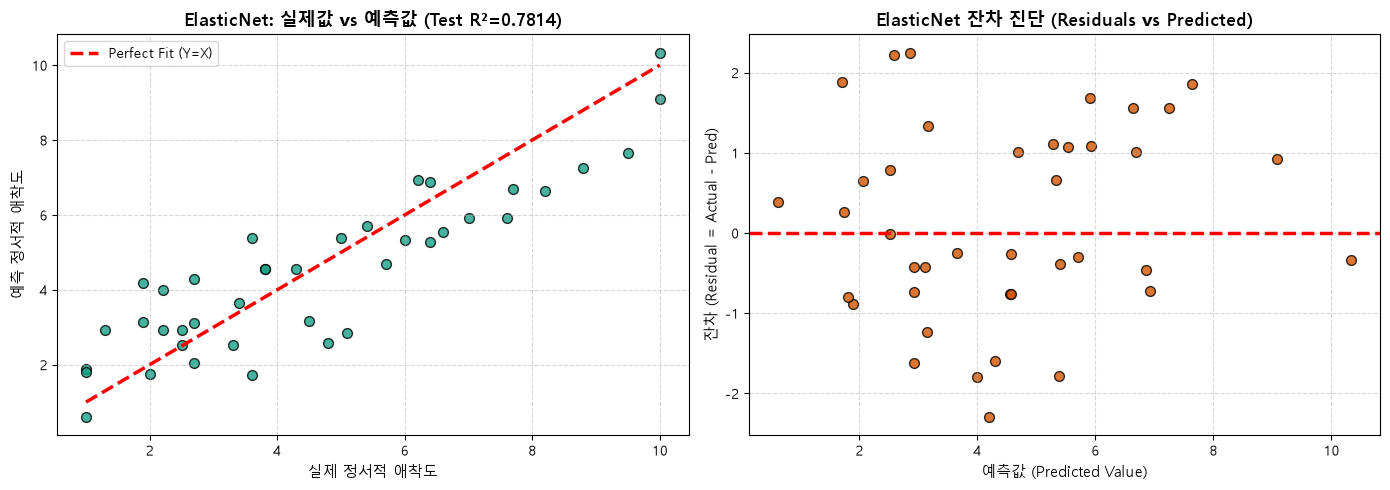

In [6]:
# ===========================================================================================================
# 8. 실제값 vs 예측값 및 잔차(Residual) 분석 시각화
# ===========================================================================================================

residuals = y_test - y_test_pred_en

plt.figure(figsize=(14, 5))

# 1) 실제값 vs 예측값 산점도
plt.subplot(1, 2, 1)
plt.scatter(y_test, y_test_pred_en, color='#16a085', alpha=0.8, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', linewidth=2.5, label='Perfect Fit (Y=X)')
plt.title(f'ElasticNet: 실제값 vs 예측값 (Test R²={test_r2:.4f})', fontsize=13, fontweight='bold')
plt.xlabel('실제 정서적 애착도', fontsize=11)
plt.ylabel('예측 정서적 애착도', fontsize=11)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)

# 2) 잔차 산점도 (Residual Plot)
plt.subplot(1, 2, 2)
plt.scatter(y_test_pred_en, residuals, color='#d35400', alpha=0.8, edgecolors='k', s=50)
plt.axhline(0, color='r', linestyle='--', linewidth=2.5)
plt.title('ElasticNet 잔차 진단 (Residuals vs Predicted)', fontsize=13, fontweight='bold')
plt.xlabel('예측값 (Predicted Value)', fontsize=11)
plt.ylabel('잔차 (Residual = Actual - Pred)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

In [7]:
import joblib

# ===========================================================================================================
# 9. 최종 ElasticNet 모델 아티팩트 저장 및 전체 모델 종합 비교
# ===========================================================================================================

# 1) ElasticNet 모델 아티팩트 저장
elastic_artifact = {
    'onehot_encoder': ohe,
    'poly_transformer': poly,
    'scaler': scaler,
    'model': elastic_cv,
    'best_alpha': best_alpha,
    'best_l1_ratio': best_l1_ratio,
    'numeric_features': numeric_features,
    'categorical_features': categorical_features
}

joblib.dump(elastic_artifact, 'elasticnet_ai_companion_model.joblib')
print('ElasticNet 모델 아티팩트 저장 완료: elasticnet_ai_companion_model.joblib')

# 2) 전체 6개 회귀 모델 성능 종합 요약표 출력
total_comparison_df = pd.DataFrame({
    '모델 종류': [
        '1. 단순 선형 회귀 (외로움)', 
        '2. 다중 선형 회귀 (전체)', 
        '3. 다항 선형 회귀 (기본, 과적합)', 
        '4. 다항 선형 회귀 (Lasso 규제)', 
        '5. 다항 선형 회귀 (Ridge 규제)', 
        '6. 다항 선형 회귀 (ElasticNet 규제)'
    ],
    '규제 유형': ['None', 'None', 'None', 'L1 (Lasso)', 'L2 (Ridge)', 'L1 + L2 (ElasticNet)'],
    'Train R²': ['0.5536', '0.7832', '1.0000', '0.7515', '0.7540', f'{train_r2:.4f}'],
    'Test R²': ['0.6448', '0.7336', '0.2627', '0.7954', '0.8045', f'{test_r2:.4f}'],
    'Test RMSE': ['1.5294', '1.3245', '2.2034', '1.1607', '1.1346', f'{test_rmse:.4f}'],
    'Test MAE': ['1.3018', '1.1082', 'N/A', '0.9971', '0.9950', f'{test_mae:.4f}']
})

print('\n=================== [AI 컴패니언 애착도 예측 전체 모델 성능 요약표] ===================')
display(total_comparison_df)

ElasticNet 모델 아티팩트 저장 완료: elasticnet_ai_companion_model.joblib

=================== [AI 컴패니언 애착도 예측 전체 모델 성능 요약표] ===================


,모델 종류,규제 유형,Train R²,Test R²,Test RMSE,Test MAE
0,1. 단순 선형 회귀 (외로움),None,0.5536,0.6448,1.5294,1.3018
1,2. 다중 선형 회귀 (전체),None,0.7832,0.7336,1.3245,1.1082
2,"3. 다항 선형 회귀 (기본, 과적합)",None,1.0000,0.2627,2.2034,N/A
3,4. 다항 선형 회귀 (Lasso 규제),L1 (Lasso),0.7515,0.7954,1.1607,0.9971
4,5. 다항 선형 회귀 (Ridge 규제),L2 (Ridge),0.7540,0.8045,1.1346,0.9950
5,6. 다항 선형 회귀 (ElasticNet 규제),L1 + L2 (ElasticNet),0.7824,0.7814,1.1997,1.0279


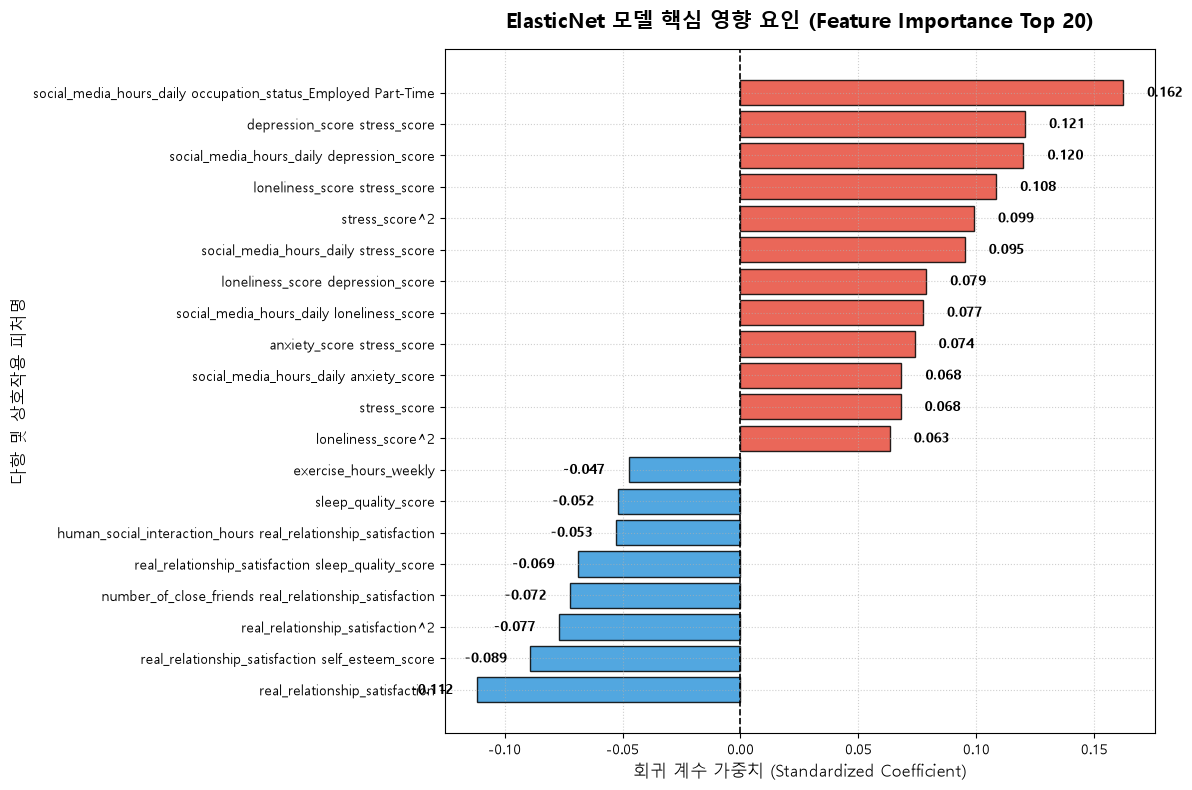

In [8]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 한글 폰트 설정 (Windows 기준: 맑은 고딕)
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 2차 다항 특성 이름 가져오기 및 계수(Coefficient) 매핑
feature_names = poly.get_feature_names_out(X.columns)
coef_df = pd.DataFrame(
    {'Feature': feature_names, 'Coefficient': elastic_cv.coef_}
)

# 2. 계수가 0이 아닌 유효 피처 추출 (총 56개)
active_features = coef_df[coef_df['Coefficient'] != 0].copy()
active_features['Abs_Coef'] = active_features['Coefficient'].abs()

# 3. 중요도(절댓값 기준) 상위 20개 피처 선정
top20_features = active_features.sort_values(
    by='Abs_Coef', ascending=False
).head(20)
top20_features = top20_features.sort_values(by='Coefficient', ascending=True)

# 4. 시각화 출력
plt.figure(figsize=(12, 8))
colors = [
    '#e74c3c' if c > 0 else '#3498db' for c in top20_features['Coefficient']
]
bars = plt.barh(
    top20_features['Feature'],
    top20_features['Coefficient'],
    color=colors,
    edgecolor='black',
    alpha=0.85,
)

plt.axvline(0, color='black', linestyle='--', linewidth=1.2)
plt.title(
    'ElasticNet 모델 핵심 영향 요인 (Feature Importance Top 20)',
    fontsize=15,
    fontweight='bold',
    pad=15,
)
plt.xlabel('회귀 계수 가중치 (Standardized Coefficient)', fontsize=12)
plt.ylabel('다항 및 상호작용 피처명', fontsize=12)
plt.grid(True, linestyle=':', alpha=0.6)

# 값 라벨 표시
for bar in bars:
  width = bar.get_width()
  ha = 'left' if width >= 0 else 'right'
  offset = 0.01 if width >= 0 else -0.01
  plt.text(
      width + offset,
      bar.get_y() + bar.get_height() / 2,
      f'{width:.3f}',
      va='center',
      ha=ha,
      fontsize=10,
      fontweight='bold',
  )

plt.tight_layout()
plt.show()


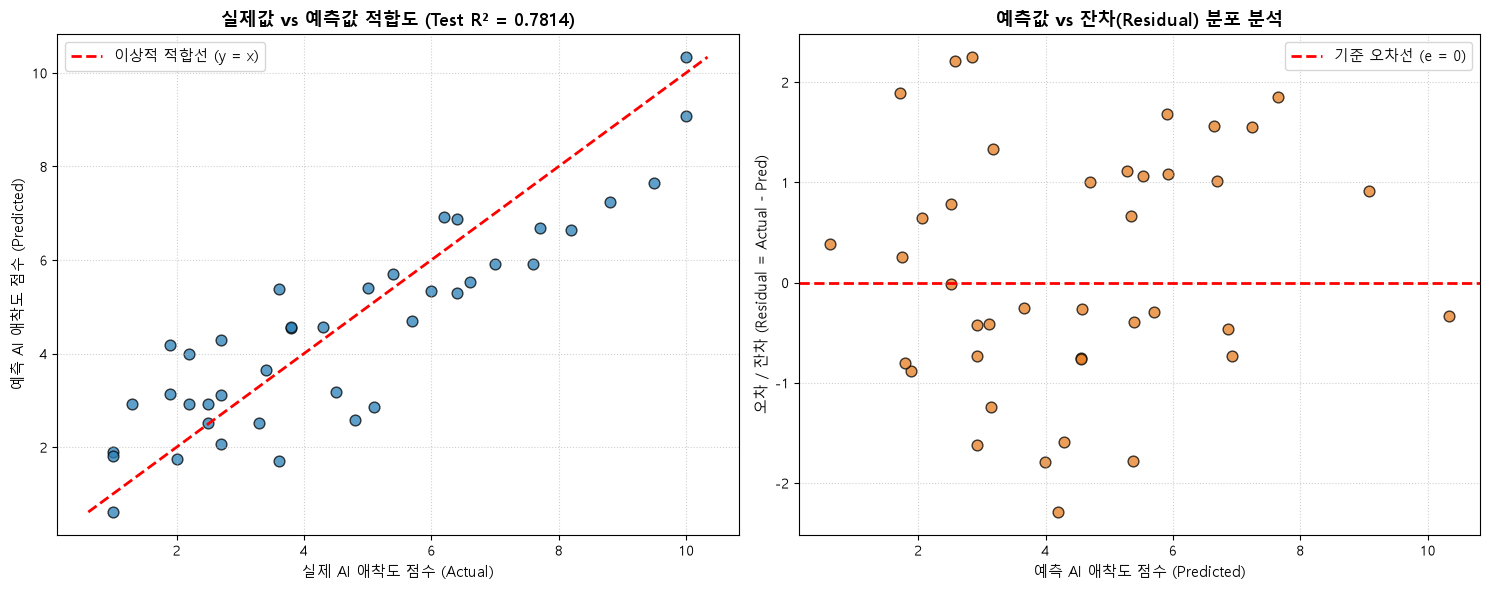

In [10]:
import matplotlib.pyplot as plt

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 1. 이미 스케일링된 X_test로 바로 예측값 및 잔차(Residual) 계산
y_test_pred = elastic_cv.predict(X_test)
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# [좌측] 실제값 vs 예측값 산점도 (Scatter Plot)
axes[0].scatter(
    y_test, y_test_pred, color='#2980b9', alpha=0.75, edgecolors='k', s=60
)
min_val = min(y_test.min(), y_test_pred.min())
max_val = max(y_test.max(), y_test_pred.max())
axes[0].plot(
    [min_val, max_val],
    [min_val, max_val],
    'r--',
    linewidth=2,
    label='이상적 적합선 (y = x)',
)
axes[0].set_title(
    f'실제값 vs 예측값 적합도 (Test R² = {test_r2:.4f})',
    fontsize=13,
    fontweight='bold',
)
axes[0].set_xlabel('실제 AI 애착도 점수 (Actual)', fontsize=11)
axes[0].set_ylabel('예측 AI 애착도 점수 (Predicted)', fontsize=11)
axes[0].legend(fontsize=11)
axes[0].grid(True, linestyle=':', alpha=0.6)

# [우측] 잔차 분포 산점도 (Residual Plot)
axes[1].scatter(
    y_test_pred, residuals, color='#e67e22', alpha=0.75, edgecolors='k', s=60
)
axes[1].axhline(
    0, color='red', linestyle='--', linewidth=2, label='기준 오차선 (e = 0)'
)
axes[1].set_title(
    '예측값 vs 잔차(Residual) 분포 분석', fontsize=13, fontweight='bold'
)
axes[1].set_xlabel('예측 AI 애착도 점수 (Predicted)', fontsize=11)
axes[1].set_ylabel('오차 / 잔차 (Residual = Actual - Pred)', fontsize=11)
axes[1].legend(fontsize=11)
axes[1].grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()


In [11]:
# 전체 모델 성능 종합 데이터프레임
total_summary_df = pd.DataFrame({
    '단계': ['1단계', '2단계', '3단계', '4단계', '5단계', '6단계'],
    '모델 구분': [
        '단순 선형 회귀 (Baseline)',
        '다중 선형 회귀 (OLS)',
        '다항 선형 회귀 (기본/과적합)',
        '다항 Lasso 회귀 (L1)',
        '다항 Ridge 회귀 (L2)',
        '다항 ElasticNet 회귀 (최종)',
    ],
    '규제 방식': [
        'None',
        'None',
        'None',
        'L1 (Lasso)',
        'L2 (Ridge)',
        'L1 + L2 (ElasticNet)',
    ],
    '피처 수': ['1개', '25개', '350개', '350개 (56개 선별)', '350개', '56개 선별'],
    'Train R²': [
        '0.5536',
        '0.7832',
        '1.0000',
        '0.7515',
        '0.7540',
        f'{train_r2:.4f}',
    ],
    'Test R²': [
        '0.6448',
        '0.7336',
        '0.2627',
        '0.7954',
        '0.8045',
        f'{test_r2:.4f}',
    ],
    'Test RMSE': [
        '1.5294',
        '1.3245',
        '2.2034',
        '1.1607',
        '1.1346',
        f'{test_rmse:.4f}',
    ],
    'Test MAE': [
        '1.3018',
        '1.1082',
        'N/A',
        '0.9971',
        '0.9950',
        f'{test_mae:.4f}',
    ],
})

print(
    '\n=================== [AI 컴패니언 의존도 예측 전체 모델 종합 성능 비교표]'
    ' ==================='
)
display(total_summary_df)



=================== [AI 컴패니언 의존도 예측 전체 모델 종합 성능 비교표] ===================


,단계,모델 구분,규제 방식,피처 수,Train R²,Test R²,Test RMSE,Test MAE
0,1단계,단순 선형 회귀 (Baseline),None,1개,0.5536,0.6448,1.5294,1.3018
1,2단계,다중 선형 회귀 (OLS),None,25개,0.7832,0.7336,1.3245,1.1082
2,3단계,다항 선형 회귀 (기본/과적합),None,350개,1.0000,0.2627,2.2034,N/A
3,4단계,다항 Lasso 회귀 (L1),L1 (Lasso),350개 (56개 선별),0.7515,0.7954,1.1607,0.9971
4,5단계,다항 Ridge 회귀 (L2),L2 (Ridge),350개,0.7540,0.8045,1.1346,0.9950
5,6단계,다항 ElasticNet 회귀 (최종),L1 + L2 (ElasticNet),56개 선별,0.7824,0.7814,1.1997,1.0279
